In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
INPUT_PATH = '/content/drive/MyDrive/KOPIS/data/complex2324_ffinal.csv'
OUT_DIR    = "/content/drive/MyDrive/KOPIS/Hyeon"

import numpy as np
import pandas as pd
import os; os.makedirs(OUT_DIR, exist_ok=True)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')


In [ ]:
# 저변 중심 가중치
W_U_PAID, W_S_PAID, W_A_PAID = 0.50, 0.30, 0.20
W_U_FREE, W_S_FREE           = 0.60, 0.40

# 접근성(편의) 보너스 민감도/캡
BETA_INCLUSION   = 0.10
BONUS_MULTIPLIER_CAP = (0.90, 1.10)

# 가드레일(유료, 회차당매출 하위20% → ×0.95)
GUARD_PENALTY    = 0.95

# 지역 보정(디밍) 수축/캡
REGION_SHRINK_K  = 60
REGION_CAP_ABS   = 5.0

usecols = [
    "공연명","예매금액_합계","판매좌석수_합계","총_공연회차_계산","최종_좌석점유율",
    "평균_판매좌석수","평균판매단가","회차당매출","접근성_점수",
    "장르명","지역","공연시설명","좌석수",
    "예측복합장르","장르1","장르2"
]

# 인코딩 자동 처리
loaded = False
for enc in ["utf-8-sig","cp949","utf-8"]:
    try:
        df = pd.read_csv(INPUT_PATH, usecols=[c for c in usecols if c], encoding=enc)
        print(f"Loaded with {enc} →", df.shape)
        loaded = True
        break
    except FileNotFoundError:
        raise
    except Exception as e:
        print(enc, "failed:", e)
if not loaded:
    raise RuntimeError("CSV 로드 실패: 인코딩/경로 확인 필요")




Loaded with utf-8-sig → (705, 16)


In [ ]:
# =========================
# 2) 전처리 & 유틸 (전역 기준)
# =========================

# 숫자형 변환
num_cols = ["예매금액_합계", "판매좌석수_합계", "총_공연회차_계산", "최종_좌석점유율",
            "평균_판매좌석수", "평균판매단가", "회차당매출", "접근성_점수"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 접근성 점수 0~11로 클립
if "접근성_점수" in df.columns:
    df["접근성_점수"] = df["접근성_점수"].clip(lower=0, upper=11)

# 이상치 제거: 최종_좌석점유율 (IQR 기준)
if "최종_좌석점유율" in df.columns:
    Q1 = df["최종_좌석점유율"].quantile(0.25)
    Q3 = df["최종_좌석점유율"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df["최종_좌석점유율"] >= lower_bound) & (df["최종_좌석점유율"] <= upper_bound)]

# 전역 윈저/백분위(코호트 없음)
def winsor_global(s: pd.Series, a=0.05, b=0.95):
    lo, hi = s.quantile(a), s.quantile(b)
    return s.clip(lo, hi)

def pct_rank_global(s: pd.Series):
    return s.rank(pct=True, method="average")


# USA 수식

In [ ]:
# =========================
# 3) U/S/A 계산 (전역 정규화)
# =========================
# U: 참여(좌석활용)
seat_occ = df["최종_좌석점유율"].astype(float).clip(upper=1.0)
p_occ = pct_rank_global(winsor_global(seat_occ))
U = p_occ.clip(0,1)

# S: 접점/규모
p_perf = pct_rank_global(winsor_global(np.log1p(df["총_공연회차_계산"].fillna(0).clip(lower=0))))
p_sold = pct_rank_global(winsor_global(np.log1p(df["판매좌석수_합계"].fillna(0).clip(lower=0))))
p_avg  = pct_rank_global(winsor_global(df["평균_판매좌석수"].astype(float)))
S = (0.5*p_perf + 0.3*p_sold + 0.2*p_avg).clip(0,1)

# A: 가격 접근성
price = pd.to_numeric(df["평균판매단가"], errors="coerce")
rev   = pd.to_numeric(df["회차당매출"], errors="coerce")

# 백분위 (0~1)
pr = price.rank(pct=True, method="max")
rr = rev.rank(pct=True, method="max")

# 1) 회차당매출 점수
A_rev = rr

# 2) 가격 점수
A_price = 1 - pr
A_price = np.where(pr < 0.5, 0.5, A_price)

# 3) 통합 (가중 기하평균)
wr, wp = 0.6, 0.4
A = (np.clip(A_rev, 1e-9, 1)**wr) * (np.clip(A_price, 1e-9, 1)**wp)
A = A ** (1.0 / (wr + wp))
df["A"] = A

# 유/무료 구분
is_free = ((df["평균판매단가"].fillna(0) <= 0) | (df["회차당매출"].fillna(0) <= 0))

# Core DPI (기하평균)
def geo(u,s,a,wu,ws,wa):
    g = (np.clip(u,1e-9,1)**wu) * (np.clip(s,1e-9,1)**ws) * (np.clip(a,1e-9,1)**wa)
    return 100 * (g ** (1.0/(wu+ws+wa)))

DPI_core_paid = geo(U,S,A, W_U_PAID, W_S_PAID, W_A_PAID)
DPI_core_free = 100 * ((np.clip(U,1e-9,1)**W_U_FREE)*(np.clip(S,1e-9,1)**W_S_FREE))
DPI_core = np.where(is_free, DPI_core_free, DPI_core_paid)

# 접근성


In [ ]:
# =========================
# 4) 접근성 보너스
# =========================

I_raw  = (df["접근성_점수"].fillna(0) / 11.0).clip(0,1)
I_pct  = pct_rank_global(winsor_global(I_raw))
I_tame = np.sqrt(I_pct)  # 상위에 약간만 보너스 주는 완만 변환
Ibar   = float(I_tame.mean())

mult   = 1 + BETA_INCLUSION * (I_tame - Ibar)
mult   = mult.clip(BONUS_MULTIPLIER_CAP[0], BONUS_MULTIPLIER_CAP[1])

DPI_plus = DPI_core * mult

p_rev = pct_rank_global(winsor_global(df["회차당매출"].astype(float)))
guard = np.where((~is_free) & (p_rev < 0.20), GUARD_PENALTY, 1.00)
DPI_plus = DPI_plus * guard


In [ ]:

df = df.copy()

# 1) U/S/A/무료여부 -> 표준 컬럼 (Series로 등록, 인덱스 정렬)
df["U_participation"] = pd.to_numeric(pd.Series(U, index=df.index), errors="coerce").astype(float)
df["S_scale"]         = pd.to_numeric(pd.Series(S, index=df.index), errors="coerce").astype(float)
df["A_afford"]        = pd.to_numeric(pd.Series(A, index=df.index), errors="coerce").astype(float)
df["is_free"]         = pd.Series(is_free, index=df.index).astype(bool)


dpi_core_s = pd.to_numeric(pd.Series(DPI_core, index=df.index), errors="coerce")

if "DPI_plus" in df.columns:
    df["DPI_plus"] = pd.to_numeric(df["DPI_plus"], errors="coerce")
    df["DPI_plus"] = df["DPI_plus"].combine_first(dpi_core_s)
else:
    df["DPI_plus"] = dpi_core_s

_need = ["U_participation","S_scale","A_afford","is_free","DPI_plus"]
_missing = [c for c in _need if c not in df.columns or df[c].isna().all()]
if _missing:
    raise RuntimeError(f"필수 컬럼 누락/전부 NaN: {_missing}. U/S/A/DPI_core 계산 확인 필요.")


# 지역 통제


In [ ]:
# ==========================================
# 세그먼트별(K, CAP) 하이퍼파라미터 탐색
# ==========================================

df["is_free"] = (price <= 0) | (rev <= 0)

df["segment"] = np.where(df["is_free"], "Free", "Paid")

# ---- 필수 컬럼 체크
for c in ["DPI_plus", "지역", "segment"]:
    if c not in df.columns:
        raise KeyError(f"필수 컬럼 없음: {c}")

# ---- 평가 그리드
K_GRID   = [30, 60, 80, 100, 150]     # 수축 정도
CAP_GRID = [2.0, 3.0, 4.0, 5.0, 6.0]  # 이동 한도(점수)

# ---- 스코어 가중치(원하면 조정)
W_ETA   = 0.40   # 지역효과(η²)
W_RMS   = 0.30   # 지역 평균의 RMS 편차
W_DIST  = 0.15   # 왜곡 크기(Δ)의 95퍼센타일
W_RANK  = 0.15   # (1 - Spearman) 낮을수록 좋음 → Spearman 높을수록 좋음
RANK_FLOOR = 0.90  # 스피어만이 이보다 낮으면 패널티 부여
RANK_PENALTY = 0.20  # 패널티 가산

def _eta2(y: pd.Series, by: pd.Series) -> float:
    """ANOVA"""
    s = pd.to_numeric(y, errors="coerce")
    m = s.mean()
    # 그룹별 평균과 크기
    g = s.groupby(by, dropna=False)
    mu = g.transform("mean")
    n  = g.transform("size")
    ss_between = ((mu - m)**2).groupby(by, dropna=False).apply(lambda z: z.iloc[0] * n.loc[z.index[0]]).sum()
    ss_total   = ((s - m)**2).sum()
    if ss_total == 0 or np.isnan(ss_total):
        return 0.0
    return float(ss_between / ss_total)

def _region_rms(y: pd.Series, by: pd.Series) -> float:
    """지역 평균의 전역평균 대비 RMS 편차"""
    s = pd.to_numeric(y, errors="coerce")
    m = s.mean()
    g = s.groupby(by, dropna=False)
    mu = g.mean()
    n  = g.size()
    if n.sum() == 0:
        return 0.0
    w = n / n.sum()
    return float(np.sqrt(((mu - m)**2 * w).sum()))

def _adjust_segment(seg_df: pd.DataFrame, K: float, CAP: float) -> pd.Series:
    """세그먼트 내부에서 지역별 디밍+수축+캡 적용 후 반환."""
    s  = pd.to_numeric(seg_df["DPI_plus"], errors="coerce")
    by = seg_df["지역"]
    g  = s.groupby(by, dropna=False)
    mu_region = g.transform("mean")
    mu_all    = float(s.mean())
    n_region  = g.transform("size")
    alpha = (n_region / (n_region + K)).clip(0,1)
    delta = np.clip(alpha * (mu_region - mu_all), -CAP, CAP)
    adj = s - delta
    return adj, (adj - s), np.abs(adj - s) >= (CAP - 1e-12)

def _spearman(a: pd.Series, b: pd.Series) -> float:
    try:
        r = a.corr(b, method="spearman")
        if pd.isna(r):
            return 1.0
        return float(r)
    except Exception:
        return 1.0

def _top_overlap(a: pd.Series, b: pd.Series, n=10) -> float:
    ia = a.rank(ascending=False, method="first").nsmallest(n).index
    ib = b.rank(ascending=False, method="first").nsmallest(n).index
    return len(set(ia) & set(ib)) / max(1, n)

def evaluate_segment(seg_name: str, seg_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    y0 = pd.to_numeric(seg_df["DPI_plus"], errors="coerce")
    by = seg_df["지역"]
    eta_pre = _eta2(y0, by)
    rms_pre = _region_rms(y0, by)

    for K in K_GRID:
        for CAP in CAP_GRID:
            adj, delta, sat = _adjust_segment(seg_df, K, CAP)
            eta_post = _eta2(adj, by)
            rms_post = _region_rms(adj, by)
            sp       = _spearman(y0, adj)
            d_mean   = float(np.abs(delta).mean())
            d_p95    = float(np.percentile(np.abs(delta.dropna()), 95)) if delta.notna().any() else 0.0
            sat_rate = float(np.mean(sat)) if len(sat) else 0.0
            top_ov   = _top_overlap(y0, adj, n=10)

            rows.append({
                "segment": seg_name,
                "K": K, "CAP": CAP,
                "eta_pre": eta_pre, "eta_post": eta_post, "eta_reduction": eta_pre - eta_post,
                "rms_pre": rms_pre, "rms_post": rms_post, "rms_reduction": rms_pre - rms_post,
                "spearman": sp, "top10_overlap": top_ov,
                "dist_mean_abs": d_mean, "dist_p95": d_p95, "cap_saturation_rate": sat_rate
            })
    res = pd.DataFrame(rows)

    # min-max 정규화
    def _minmax(s):
        v = s.values.astype(float)
        v = (v - np.nanmin(v)) / (np.nanmax(v) - np.nanmin(v) + 1e-12)
        return pd.Series(v, index=s.index)

    if not res.empty:
        bad_eta  = _minmax(res["eta_post"])
        bad_rms  = _minmax(res["rms_post"])
        bad_dist = _minmax(res["dist_p95"])
        bad_rank = _minmax(1 - res["spearman"])
        score = W_ETA*bad_eta + W_RMS*bad_rms + W_DIST*bad_dist + W_RANK*bad_rank


        score += np.where(res["spearman"] < RANK_FLOOR, RANK_PENALTY, 0.0)
        res["score"] = score

        res = res.sort_values(["score","eta_post","rms_post","dist_p95"], ascending=True).reset_index(drop=True)
    return res

# 세그먼트별 평가 실행
results = []
for seg in ["Paid","Free"]:
    seg_df = df[df["segment"] == seg]
    if len(seg_df) == 0:
        print(f"{seg}: 데이터 없음")
        continue
    res = evaluate_segment(seg, seg_df)
    results.append(res)
    print(f"\n=== 후보표: {seg} (상위 10) ===")
    display(res.head(10))

# 최적값 자동 선택 및 적용
APPLY_BEST = True

if results:
    best_params = {}
    for res in results:
        seg = res.loc[0, "segment"]
        K_best  = res.loc[0, "K"]
        CAP_best= res.loc[0, "CAP"]
        best_params[seg] = {"K": float(K_best), "CAP": float(CAP_best)}
        print(f"[BEST] {seg} → K={K_best}, CAP={CAP_best} | score={res.loc[0,'score']:.4f}, "
              f"eta_post={res.loc[0,'eta_post']:.4f}, spearman={res.loc[0,'spearman']:.3f}, "
              f"rms_post={res.loc[0,'rms_post']:.3f}, d95={res.loc[0,'dist_p95']:.2f}, cap_sat={res.loc[0,'cap_saturation_rate']:.2%}")

    if APPLY_BEST:
        for c in ["DPI_region_adj_seg","DPI_region_pr_seg","region_delta_seg"]:
            df[c] = np.nan

        for seg, hp in best_params.items():
            idx = (df["segment"] == seg)
            if not idx.any(): continue
            seg_df = df.loc[idx]
            # 적용
            adj, delta, _ = _adjust_segment(seg_df, hp["K"], hp["CAP"])
            pr = seg_df["DPI_plus"].groupby(seg_df["지역"], dropna=False).rank(pct=True, method="average")
            df.loc[idx, "DPI_region_adj_seg"] = adj.values
            df.loc[idx, "DPI_region_pr_seg"]  = pr.values
            df.loc[idx, "region_delta_seg"]   = (adj - seg_df["DPI_plus"]).values

        print("\n✅ 최적 K/CAP 적용 완료")
else:
    print("평가 결과가 없습니다.")



=== 후보표: Paid (상위 10) ===


,segment,K,CAP,eta_pre,eta_post,eta_reduction,rms_pre,rms_post,rms_reduction,spearman,top10_overlap,dist_mean_abs,dist_p95,cap_saturation_rate,score
0,Paid,30,4.0,0.017344,0.005187,0.012157,2.329456,1.266114,1.063342,0.996456,0.9,1.057538,3.110167,0.000000,0.300000
1,Paid,30,5.0,0.017344,0.005187,0.012157,2.329456,1.266114,1.063342,0.996456,0.9,1.057538,3.110167,0.000000,0.300000
2,Paid,30,6.0,0.017344,0.005187,0.012157,2.329456,1.266114,1.063342,0.996456,0.9,1.057538,3.110167,0.000000,0.300000
3,Paid,30,3.0,0.017344,0.005329,0.012015,2.329456,1.283391,1.046065,0.996538,0.9,1.050069,3.000000,0.067797,0.306376
4,Paid,30,2.0,0.017344,0.006842,0.010502,2.329456,1.455335,0.874121,0.997198,0.9,0.981580,2.000000,0.294492,0.392919
5,Paid,60,3.0,0.017344,0.007450,0.009894,2.329456,1.519106,0.810350,0.997784,0.9,0.831914,2.095982,0.000000,0.443684
6,Paid,60,4.0,0.017344,0.007450,0.009894,2.329456,1.519106,0.810350,0.997784,0.9,0.831914,2.095982,0.000000,0.443684
7,Paid,60,5.0,0.017344,0.007450,0.009894,2.329456,1.519106,0.810350,0.997784,0.9,0.831914,2.095982,0.000000,0.443684
8,Paid,60,6.0,0.017344,0.007450,0.009894,2.329456,1.519106,0.810350,0.997784,0.9,0.831914,2.095982,0.000000,0.443684
9,Paid,60,2.0,0.017344,0.007614,0.009729,2.329456,1.535901,0.793555,0.997821,0.9,0.825407,2.000000,0.067797,0.454930



=== 후보표: Free (상위 10) ===


,segment,K,CAP,eta_pre,eta_post,eta_reduction,rms_pre,rms_post,rms_reduction,spearman,top10_overlap,dist_mean_abs,dist_p95,cap_saturation_rate,score
0,Free,30,5.0,0.050644,0.008599,0.042046,4.992352,2.013000,2.979352,0.991321,0.7,2.613849,4.797336,0.000000,0.300000
1,Free,30,6.0,0.050644,0.008599,0.042046,4.992352,2.013000,2.979352,0.991321,0.7,2.613849,4.797336,0.000000,0.300000
2,Free,30,4.0,0.050644,0.011083,0.039561,4.992352,2.288243,2.704108,0.992927,0.8,2.435497,4.000000,0.223684,0.315063
3,Free,30,3.0,0.050644,0.014960,0.035685,4.992352,2.663716,2.328636,0.994286,1.0,2.198319,3.000000,0.565789,0.366557
4,Free,60,4.0,0.050644,0.017189,0.033455,4.992352,2.858567,2.133785,0.995483,1.0,1.862441,3.500759,0.000000,0.440320
5,Free,60,5.0,0.050644,0.017189,0.033455,4.992352,2.858567,2.133785,0.995483,1.0,1.862441,3.500759,0.000000,0.440320
6,Free,60,6.0,0.050644,0.017189,0.033455,4.992352,2.858567,2.133785,0.995483,1.0,1.862441,3.500759,0.000000,0.440320
7,Free,60,3.0,0.050644,0.019267,0.031378,4.992352,3.029575,1.962776,0.995820,1.0,1.750429,3.000000,0.223684,0.472995
8,Free,80,3.0,0.050644,0.021409,0.029236,4.992352,3.197033,1.795319,0.996606,1.0,1.563983,2.966292,0.000000,0.521304
9,Free,80,4.0,0.050644,0.021409,0.029236,4.992352,3.197033,1.795319,0.996606,1.0,1.563983,2.966292,0.000000,0.521304


[BEST] Paid → K=30, CAP=4.0 | score=0.3000, eta_post=0.0052, spearman=0.996, rms_post=1.266, d95=3.11, cap_sat=0.00%
[BEST] Free → K=30, CAP=5.0 | score=0.3000, eta_post=0.0086, spearman=0.991, rms_post=2.013, d95=4.80, cap_sat=0.00%

✅ 최적 K/CAP 적용 완료


In [ ]:
# =========================
# 6) 저장(정렬/파일 분리)
# =========================

desired_cols = [
    "공연명","장르명","지역","공연시설명",
    "최종_좌석점유율","총_공연회차_계산","판매좌석수_합계","평균_판매좌석수",
    "평균판매단가","회차당매출","접근성_점수", "좌석수",
    "예측복합장르","장르1","장르2",
    # DPI 구성요소/최종값
    "U_participation","S_scale","A_afford","DPI_core","DPI_plus",
    "DPI_region_adj_seg","DPI_region_pr_seg","is_free"
]
rank_cols = [c for c in desired_cols if c in df.columns]

sort_keys = ["DPI_region_adj_seg","U_participation","S_scale","A_afford"]

# 세그먼트별 저장 (Paid / Free)
for seg in ["Paid", "Free"]:
    seg_df = df[df["segment"] == seg].copy()
    if seg_df.empty:
        print(f"{seg}: 저장할 데이터가 없습니다.")
        continue

    seg_rank = seg_df.sort_values(sort_keys, ascending=[False,False,False,False])[rank_cols]

    # 1) 세그먼트 전체 파일
    out_seg = f"{OUT_DIR}/DPI_ranked_{seg}.csv"
    seg_rank.to_csv(out_seg, index=False, encoding="utf-8-sig")
    print("Saved:", out_seg, "| rows:", len(seg_rank))

Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Paid.csv | rows: 472
Saved: /content/drive/MyDrive/KOPIS/Hyeon/DPI_ranked_Free.csv | rows: 228


In [ ]:
print(df.columns)


Index(['공연명', '총_공연회차_계산', '평균_판매좌석수', '예매금액_합계', '판매좌석수_합계', '최종_좌석점유율',
       '평균판매단가', '회차당매출', '접근성_점수', '장르명', '지역', '공연시설명', '좌석수', '예측복합장르',
       '장르1', '장르2', 'A', 'U_participation', 'S_scale', 'A_afford', 'is_free',
       'DPI_plus', 'segment', 'DPI_region_adj_seg', 'DPI_region_pr_seg',
       'region_delta_seg'],
      dtype='object')


In [ ]:

!apt-get update -qq
!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("폰트 파일이 존재하지 않습니다.")


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from font",
    category=UserWarning,
    module="matplotlib"
)

warnings.filterwarnings("ignore", category=FutureWarning)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.


# 지역별 / 규모별 비교 시각화




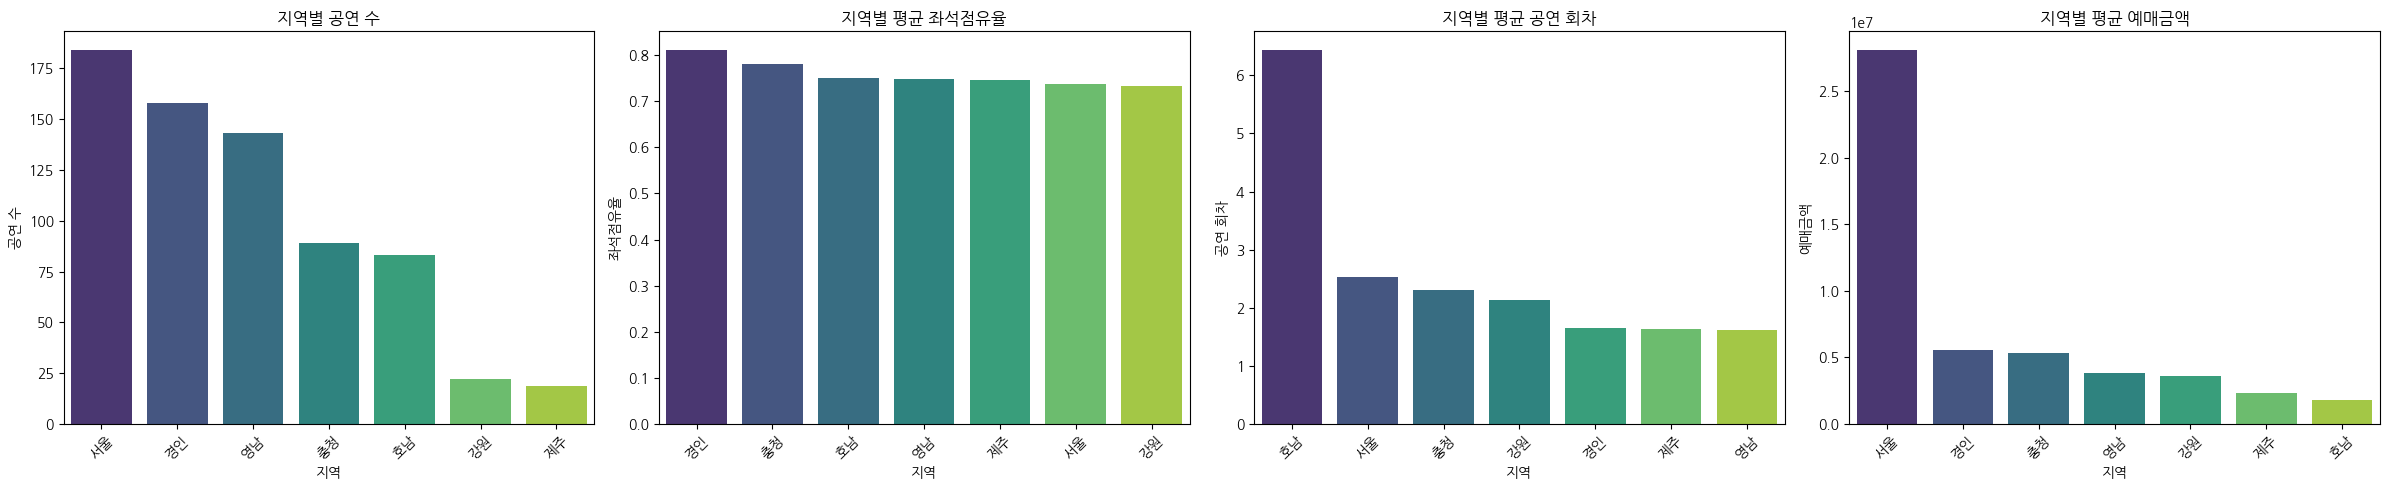

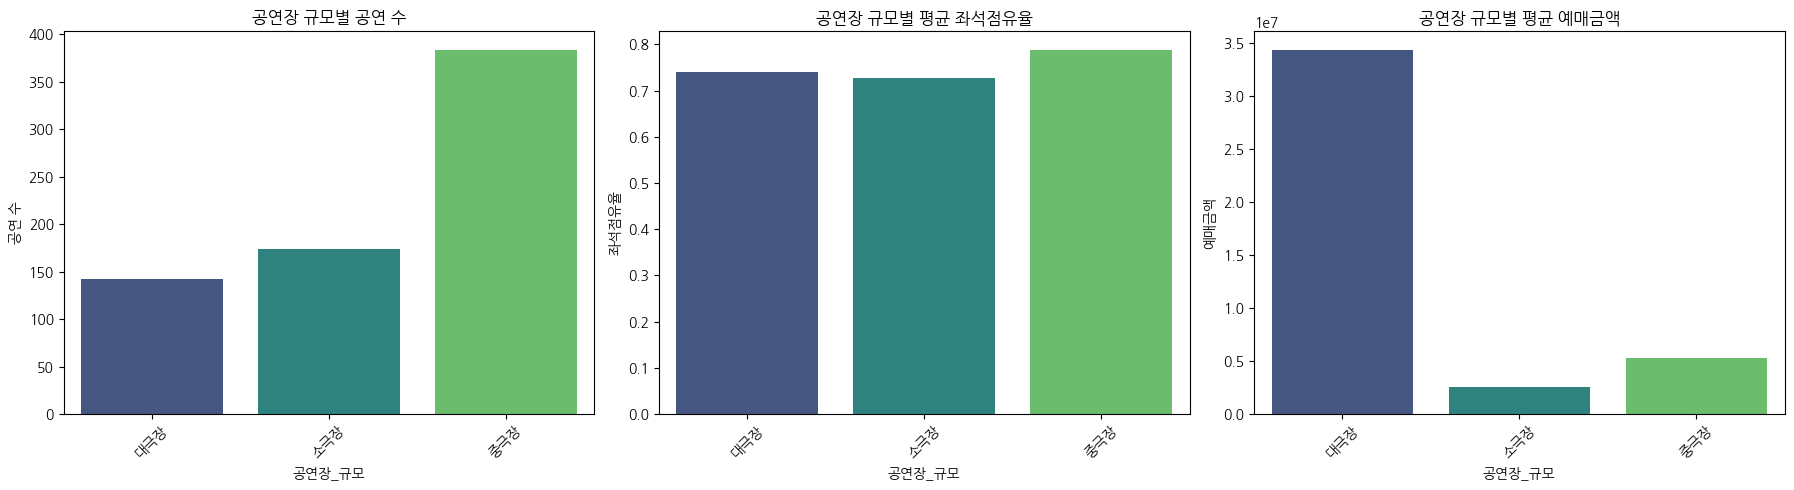

In [ ]:


save_dir = "/content/drive/MyDrive/KOPIS/Hyeon"


num_cols = ["최종_좌석점유율", "총_공연회차_계산", "판매좌석수_합계", "예매금액_합계", "좌석수"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["지역"] = df["지역"].replace("기타", "강원")

# 공연장 규모 분류
def classify_venue(seat_count):
    if seat_count < 300:
        return "소극장"
    elif seat_count < 1000:
        return "중극장"
    else:
        return "대극장"

df["공연장_규모"] = df["좌석수"].apply(classify_venue)

# 요약 통계
region_summary = df.groupby("지역").agg(
    공연_수=("공연명", "count"),
    평균_좌석점유율=("최종_좌석점유율", "mean"),
    평균_공연회차=("총_공연회차_계산", "mean"),
    평균_판매좌석수=("판매좌석수_합계", "mean"),
    평균_예매금액=("예매금액_합계", "mean")
).reset_index()

venue_summary = df.groupby("공연장_규모").agg(
    공연_수=("공연명", "count"),
    평균_좌석점유율=("최종_좌석점유율", "mean"),
    평균_공연회차=("총_공연회차_계산", "mean"),
    평균_판매좌석수=("판매좌석수_합계", "mean"),
    평균_예매금액=("예매금액_합계", "mean")
).reset_index()


def plot_multiple_bars(data, x_col, y_cols, titles, ylabels, filename_prefix, sort=True):
    num_plots = len(y_cols)
    cols = 4
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for i, y_col in enumerate(y_cols):
        plot_data = data.copy()
        if sort:
            plot_data = plot_data.sort_values(y_col, ascending=False)

        sns.barplot(data=plot_data, x=x_col, y=y_col, ax=axes[i], palette="viridis")
        axes[i].set_title(titles[i])
        axes[i].set_ylabel(ylabels[i])
        axes[i].set_xlabel(x_col)
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# 지역별 시각화
plot_multiple_bars(
    data=region_summary,
    x_col="지역",
    y_cols=["공연_수", "평균_좌석점유율", "평균_공연회차", "평균_예매금액"],
    titles=[
        "지역별 공연 수", "지역별 평균 좌석점유율", "지역별 평균 공연 회차", "지역별 평균 예매금액"
    ],
    ylabels=["공연 수", "좌석점유율", "공연 회차", "예매금액"],
    filename_prefix="지역별분포"
)

# 공연장 규모별 시각화
plot_multiple_bars(
    data=venue_summary.sort_values("공연장_규모"),  # 순서 고정
    x_col="공연장_규모",
    y_cols=["공연_수", "평균_좌석점유율", "평균_예매금액"],
    titles=[
        "공연장 규모별 공연 수", "공연장 규모별 평균 좌석점유율", "공연장 규모별 평균 예매금액"
    ],
    ylabels=["공연 수", "좌석점유율", "예매금액"],
    filename_prefix="공연장규모별분포",
    sort=False
)


# 지역별 / 규모별 성과 표


In [ ]:

def format_summary_table(df, num_format_cols, percentage_cols=[], int_cols=[]):
    df_fmt = df.copy()
    for col in num_format_cols:
        if col in df.columns:
            df_fmt[col] = df[col].apply(lambda x: f"{x:,.0f}")
    for col in percentage_cols:
        if col in df.columns:
            df_fmt[col] = df[col].apply(lambda x: f"{x:.3f}")
    for col in int_cols:
        if col in df.columns:
            df_fmt[col] = df[col].astype(int)
    return df_fmt

region_summary_fmt = region_summary.rename(columns={
    "공연_수": "공연 수",
    "평균_좌석점유율": "평균 좌석점유율",
    "평균_공연회차": "평균 공연회차",
    "평균_판매좌석수": "평균 판매좌석수",
    "평균_예매금액": "평균 예매금액"
})

venue_summary_fmt = venue_summary.rename(columns={
    "공연_수": "공연 수",
    "평균_좌석점유율": "평균 좌석점유율",
    "평균_공연회차": "평균 공연회차",
    "평균_판매좌석수": "평균 판매좌석수",
    "평균_예매금액": "평균 예매금액"
})

cols_money = ["평균 판매좌석수", "평균 예매금액"]
cols_ratio = ["평균 좌석점유율"]
cols_round = ["평균 공연회차"]
cols_count = ["공연 수"]

region_summary_fmt = format_summary_table(region_summary_fmt, num_format_cols=cols_money + cols_round,
                                          percentage_cols=cols_ratio, int_cols=cols_count)

venue_summary_fmt = format_summary_table(venue_summary_fmt, num_format_cols=cols_money + cols_round,
                                         percentage_cols=cols_ratio, int_cols=cols_count)


from IPython.display import display, Markdown

display(Markdown("### 📍 지역별 복합 장르 공연 요약"))
display(region_summary_fmt)

display(Markdown("### 📍 공연장 규모별 복합 장르 공연 요약"))
display(venue_summary_fmt)


### 📍 지역별 복합 장르 공연 요약

,지역,공연 수,평균 좌석점유율,평균 공연회차,평균 판매좌석수,평균 예매금액
0,강원,22,0.732,2,747,"3,623,386"
1,경인,158,0.811,2,635,"5,594,029"
2,서울,184,0.737,3,"1,583","28,066,466"
3,영남,143,0.749,2,636,"3,858,428"
4,제주,19,0.746,2,888,"2,300,500"
5,충청,89,0.780,2,810,"5,311,431"
6,호남,83,0.750,6,"1,803","1,777,648"


### 📍 공연장 규모별 복합 장르 공연 요약

,공연장_규모,공연 수,평균 좌석점유율,평균 공연회차,평균 판매좌석수,평균 예매금액
0,대극장,142,0.740,2,"2,396","34,405,094"
1,소극장,174,0.727,5,905,"2,579,314"
2,중극장,384,0.789,2,629,"5,253,997"
